# Optimal Roth Conversion Schedules Are Lumpy, Not Smooth

This notebook is the companion to the article *"The optimal Roth conversion schedule is
lumpy, and every rule of thumb misses it."* It reproduces every number in that post from a
single, auditable, ~300-line Python model (`scenario_a.py` in this repo), so you can check the
math, change the assumptions, and re-run it yourself.

**As of current law, July 2026.** Every constant below (tax brackets, ACA cliff, IRMAA tiers,
FPL) is the actual legislated 2026 figure, cited to its source. Nothing here is a forecast or an
opinion about what the rules *should* be — it's an optimization over the rules as they exist
today, which happen to include several genuine cliffs (a dollar over the line costs you a fixed
amount of money, not a marginal amount).

**Every constant in the model is a swappable parameter.** Section 2 shows you where they live;
change your own IRA balance, state's ACA premium, or heir tax rate and re-run the whole notebook.

## Scenario at a glance

| Parameter | Value |
|---|---|
| Filing status | Married filing jointly, no state income tax |
| Ages (Jan 1, 2026) | 60 and 58 |
| Traditional IRA | \$1,500,000 |
| Taxable brokerage | \$600,000 (basis \$540,000, i.e. \$60,000 unrealized gain) |
| Roth IRA | \$200,000 |
| Annual spending | \$70,000/yr, real (today's dollars) |
| Social Security | \$30,000/yr each, both claim at age 70 |
| Health insurance (pre-65) | ACA marketplace, benchmark silver ≈ \$22,600/yr (national average) |
| Investment return | 4% real, deterministic, on every account (no Monte Carlo — see below) |
| Horizon | 30 years, elder spouse age 60 → 90 |
| Objective | After-tax estate value at age 90; inherited IRA discounted at heir's marginal rate (24% default), taxable account gets a full basis step-up |

Why deterministic returns instead of Monte Carlo: this is a *tax problem*, not a *returns
problem*. Every cliff in the tax code below is a cliff regardless of what the market does, and
the qualitative result (bang-bang, lumpy conversions) survives at any reasonable fixed return
you plug in. If you want to bolt a return distribution on top of this, the conversion *schedule*
is the object of interest — the code is structured so you can swap `R = 0.04` for a stochastic
path per-year without touching the tax logic.


In [1]:
# All model logic lives in scenario_a.py — single source of truth for both
# the article and this notebook. Nothing below re-derives the tax math; we
# only import it, run it, and display it.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scenario_a import *

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11


## 2. The 2026 constants, with sources

These are pulled directly from the `scenario_a.py` module you just imported — the values below
are *live*, not retyped, so if the source file changes the table changes with it. Full source
list and cross-checks are in `constants-2026.md` in this repo.


In [2]:
import pandas as pd

const_table = [
    ("Standard deduction (MFJ)",            f"${STD_DED:,.0f}",         "IRS Rev. Proc. 2025-32"),
    ("10%/12% bracket boundary",            f"${BRACKETS[1][0]:,.0f}",  "IRS Rev. Proc. 2025-32"),
    ("12%/22% bracket boundary",            f"${BRACKETS[2][0]:,.0f}",  "IRS Rev. Proc. 2025-32 (corrected; see Sec. 8)"),
    ("22%/24% bracket boundary",            f"${BRACKETS[3][0]:,.0f}",  "IRS Rev. Proc. 2025-32"),
    ("24%/32% bracket boundary",            f"${BRACKETS[4][0]:,.0f}",  "IRS Rev. Proc. 2025-32"),
    ("37% bracket floor",                   f"${BRACKETS[-1][0]:,.0f}", "IRS Rev. Proc. 2025-32"),
    ("LTCG 0%->15% threshold (MFJ)",        f"${LTCG_0_TOP:,.0f}",      "IRS Rev. Proc. 2025-32"),
    ("LTCG 15%->20% threshold (MFJ)",       f"${LTCG_15_TOP:,.0f}",     "IRS Rev. Proc. 2025-32"),
    ("NIIT threshold (MFJ, not indexed)",   f"${NIIT_THRESH:,.0f}",     "IRC Sec. 1411 / IRS Topic 559"),
    ("NIIT rate",                           f"{NIIT_RATE:.1%}",         "IRC Sec. 1411"),
    ("SS provisional income tier 1 (MFJ)",  f"${SS_T1:,.0f}",           "IRC Sec. 86 / IRS Pub. 915 (not indexed)"),
    ("SS provisional income tier 2 (MFJ)",  f"${SS_T2:,.0f}",           "IRC Sec. 86 / IRS Pub. 915 (not indexed)"),
    ("ACA cliff: 400% FPL, 2-person HH",    f"${FPL400:,.0f}",          "ASPE 2025 poverty guidelines (for 2026 coverage)"),
    ("IRMAA first tier floor (MFJ)",        f"${IRMAA_TIERS[0][0]:,.0f}", "CMS 2026 premium notice"),
    ("IRMAA first-tier annual surcharge (per person)", f"${IRMAA_TIERS[0][1]:,.0f}", "CMS 2026 premium notice"),
    ("ACA benchmark premium (nat'l avg, 60yo couple)", f"${ACA_PREMIUM_COUPLE:,.0f}/yr", "KFF subsidy calculator"),
    ("RMD start age (born 1960+)",          f"{RMD_START}",             "SECURE 2.0 Act Sec. 107"),
    ("Heir marginal rate (default)",        f"{HEIR_RATE:.0%}",         "Scenario assumption -- swap freely"),
]
df_const = pd.DataFrame(const_table, columns=["Constant", "2026 value", "Source"])
df_const


,Constant,2026 value,Source
0,Standard deduction (MFJ),"$32,200",IRS Rev. Proc. 2025-32
1,10%/12% bracket boundary,"$24,800",IRS Rev. Proc. 2025-32
2,12%/22% bracket boundary,"$100,800",IRS Rev. Proc. 2025-32 (corrected; see Sec. 8)
3,22%/24% bracket boundary,"$211,400",IRS Rev. Proc. 2025-32
4,24%/32% bracket boundary,"$403,550",IRS Rev. Proc. 2025-32
5,37% bracket floor,"$768,700",IRS Rev. Proc. 2025-32
6,LTCG 0%->15% threshold (MFJ),"$98,900",IRS Rev. Proc. 2025-32
7,LTCG 15%->20% threshold (MFJ),"$613,700",IRS Rev. Proc. 2025-32
8,"NIIT threshold (MFJ, not indexed)","$250,000",IRC Sec. 1411 / IRS Topic 559
9,NIIT rate,3.8%,IRC Sec. 1411


All indexed thresholds above are held fixed in real (today's) dollars for the full
30-year horizon; non-indexed thresholds (NIIT, Social Security provisional income) are deflated
each year at the assumed 2.5% inflation rate, since the tax code doesn't adjust them and their
real value erodes over time (part of why the "tax torpedo" gets worse for later cohorts).


## 3. Five policies, one model

We run the same `simulate()` engine — the one that produces every dollar figure in the article —
against five conversion strategies:

1. **No conversions** — baseline.
2. **Fill the 12% bracket** every year the IRA still has a balance.
3. **Fill the 24% bracket** every year — the popular "you'll pay more later via RMDs, so convert
   now" advice.
4. **Cliff-aware greedy** — convert up to just under the ACA cliff each year while on
   marketplace insurance, then switch to filling the 24% bracket after 65. This is what a
   diligent DIY planner who's read the forum threads on IRMAA/ACA actually does.
5. **Full 30-year joint optimization** — a coordinate-ascent search (`optimize()` in
   `scenario_a.py`) over all 31 years of conversion amounts simultaneously. This is the slow
   one (multi-minute run with multi-start + refinement passes), so **we do not re-run it here**.
   Instead we hardcode the frozen optimal schedule found by `optimize()` and simulated it below —
   you can reproduce the search yourself with the commented-out call.


In [3]:
# Policies 1-4: cheap, re-run live every time.
policies = {
    "1. No conversions":            np.zeros(YEARS),
    "2. Fill 12% bracket":          policy_fill_bracket(BRACKETS[2][0]),
    "3. Fill 24% bracket":          policy_fill_bracket(BRACKETS[3][0]),
    "4. Cliff-aware greedy":        policy_cliff_greedy(),
}

# Policy 5: the frozen optimal schedule, taken verbatim from the nonzero-year
# printout in results_frozen.txt (elder-spouse age -> conversion amount).
# To re-derive it yourself (several minutes on a laptop):
#
#     seeds = [np.zeros(YEARS), policies["4. Cliff-aware greedy"],
#              policies["2. Fill 12% bracket"]]  # + bang-bang seeds, see scenario_a.py __main__
#     c_opt, v_opt = optimize(seeds)
#
optimal_schedule = np.zeros(YEARS)
# age -> conversion, from results_frozen.txt "Optimized conversion path"
_frozen = {
    60: 355_000, 61: 65_000, 62: 120_000, 63: 605_000, 64: 310_000,
    72: 10_000, 73: 10_000, 74: 10_000, 75: 15_000, 76: 8_500,
    77: 10_000, 78: 10_000, 79: 10_000, 80: 9_000, 81: 9_500,
    82: 10_000, 83: 10_000, 84: 5_000, 85: 5_000, 86: 5_000, 87: 5_000,
}
for age, amt in _frozen.items():
    optimal_schedule[age - AGE1_0] = amt
policies["5. Full 30-year optimum"] = optimal_schedule

results = {name: simulate(c) for name, c in policies.items()}
base = results["1. No conversions"]

comparison = pd.DataFrame(
    [(name, v, v - base) for name, v in results.items()],
    columns=["Policy", "Estate at 90 (real $)", "vs. no conversions"],
)
comparison["Estate at 90 (real $)"] = comparison["Estate at 90 (real $)"].map(lambda v: f"${v:,.0f}")
comparison["vs. no conversions"] = comparison["vs. no conversions"].map(lambda v: f"{v:+,.0f}")
comparison


,Policy,Estate at 90 (real $),vs. no conversions
0,1. No conversions,"$4,689,159",+0
1,2. Fill 12% bracket,"$5,040,823","+351,663"
2,3. Fill 24% bracket,"$4,338,429","-350,730"
3,4. Cliff-aware greedy,"$4,909,741","+220,582"
4,5. Full 30-year optimum,"$5,405,554","+716,394"


In [4]:
# Sanity check against the frozen headline numbers quoted in the article.
opt_estate = results["5. Full 30-year optimum"]
greedy_estate = results["4. Cliff-aware greedy"]
print(f"Optimum estate @ 90:            ${opt_estate:,.0f}   (article/frozen: $5,405,554)")
print(f"Optimum vs. cliff-aware greedy: ${opt_estate - greedy_estate:,.0f}   (article: ~$496k)")
assert abs(opt_estate - 5_405_554) < 1.0, "Optimal schedule did not reproduce the frozen headline number"
assert 400_000 < (opt_estate - greedy_estate) < 600_000, "Optimum-vs-greedy gap out of expected range"
print("\nBoth headline numbers reproduced.")


Optimum estate @ 90:            $5,405,554   (article/frozen: $5,405,554)
Optimum vs. cliff-aware greedy: $495,813   (article: ~$496k)

Both headline numbers reproduced.


## 4. Chart 1 — Estate at 90, by policy

The optimum beats every heuristic, including the popular "fill the 24% bracket" advice, which
is actually *worse than doing nothing* for this couple (it torches the ACA subsidy for five
straight years and the bracket arbitrage never earns it back).


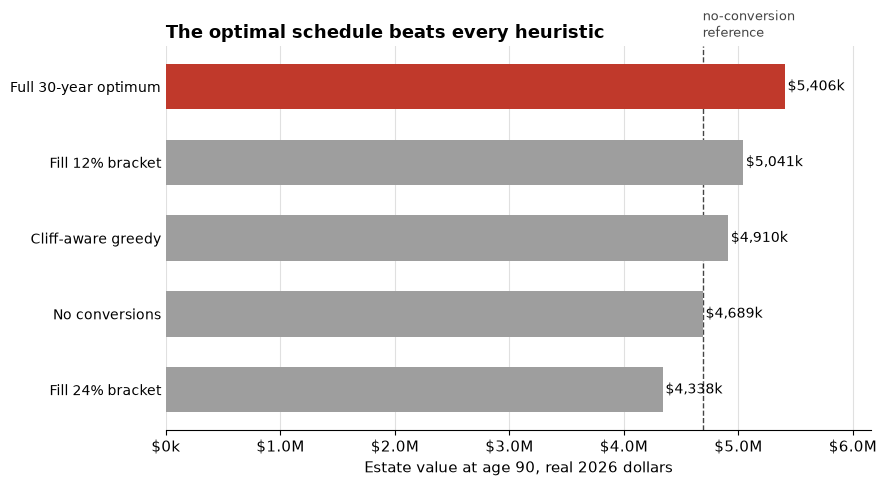

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

order = ["3. Fill 24% bracket", "1. No conversions", "4. Cliff-aware greedy",
         "2. Fill 12% bracket", "5. Full 30-year optimum"]
values = [results[k] for k in order]
colors = ["#9e9e9e"] * len(order)
colors[order.index("5. Full 30-year optimum")] = "#c0392b"

y_pos = np.arange(len(order))
bars = ax.barh(y_pos, values, color=colors, height=0.6, zorder=3)

no_conv = results["1. No conversions"]
ax.axvline(no_conv, color="#444444", linestyle="--", linewidth=1, zorder=2)
ax.text(no_conv, len(order) - 0.4, "no-conversion\nreference", fontsize=9,
        ha="left", va="bottom", color="#444444")

for bar, v in zip(bars, values):
    ax.text(v + 25_000, bar.get_y() + bar.get_height() / 2, f"${v/1000:,.0f}k",
            va="center", ha="left", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels([k[3:] for k in order], fontsize=10)
ax.set_xlabel("Estate value at age 90, real 2026 dollars")
ax.set_xlim(0, max(values) * 1.14)
ax.set_title("The optimal schedule beats every heuristic", fontsize=13, fontweight="bold", loc="left")
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1000:.0f}k"))
ax.grid(axis="x", color="#e0e0e0", linewidth=0.8, zorder=0)

plt.tight_layout()
plt.savefig("charts/chart1_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Chart 2 — The optimal schedule is bang-bang

Three huge conversion years (ages 60, 63, 64) blow straight through the ACA cliff on purpose;
everything in between and after is near-zero or a small mop-up. Age 62 is the interesting
interior case: the optimizer *gives up* that year's ACA credit to buy cheap 12%-bracket space,
which no simple rule of thumb produces.


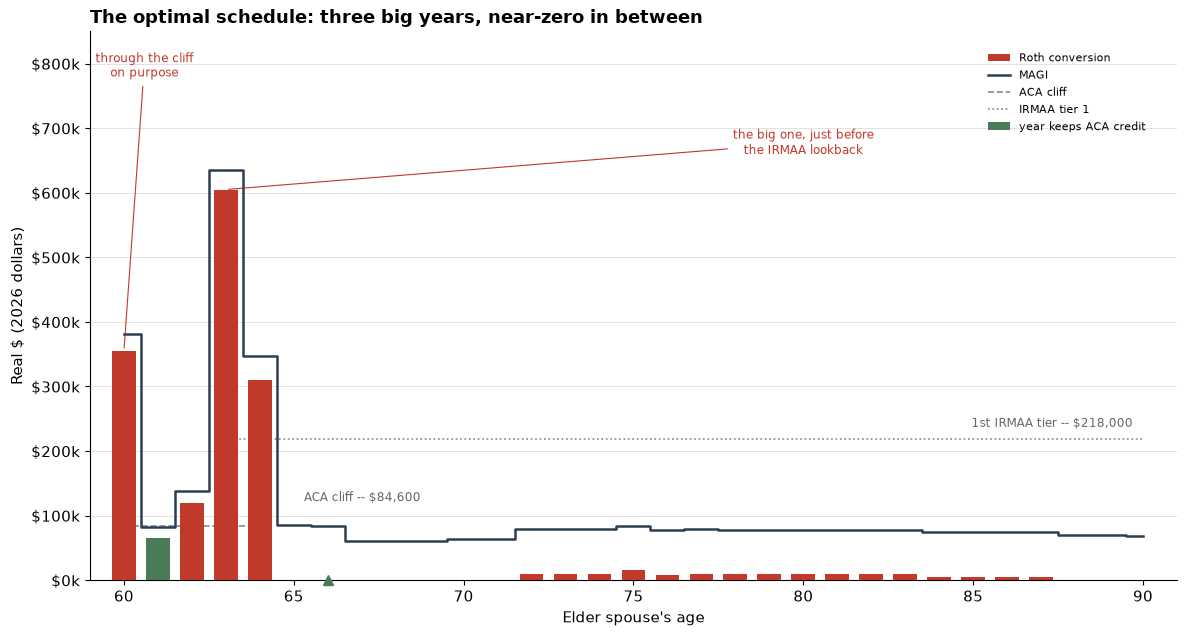

In [6]:
_, detail_rows = simulate(optimal_schedule, detail=True)
ages = [r["a1"] for r in detail_rows]
convs = [r["conv"] for r in detail_rows]
magis = [r["magi"] for r in detail_rows]
credit_kept_ages = [r["a1"] for r in detail_rows if r["subsidy"] > 0]

RED = "#c0392b"
DARK = "#2c3e50"
GREEN = "#4a7c59"
GREY = "#888888"

fig, ax = plt.subplots(figsize=(12, 6.5))

bar_colors = [GREEN if a in credit_kept_ages else RED for a in ages]
ax.bar(ages, convs, color=bar_colors, width=0.7, zorder=3)

# mark credit-kept years that have a zero-height bar with a small baseline tick
for a in credit_kept_ages:
    if convs[ages.index(a)] == 0:
        ax.plot(a, 0, marker="^", color=GREEN, markersize=7, zorder=4, clip_on=False)

ax.step(ages, magis, where="mid", color=DARK, linewidth=1.8, zorder=4)

ax.set_xlabel("Elder spouse's age")
ax.set_ylabel("Real $ (2026 dollars)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
ax.set_ylim(0, 850_000)
ax.set_xlim(min(ages) - 1, max(ages) + 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# ACA cliff -- relevant only while under-65 coverage is in play (ages 60-64)
aca_ages = [a for a in ages if a <= 64]
ax.hlines(FPL400, min(aca_ages), max(aca_ages), color=GREY, linestyle="--", linewidth=1.2, zorder=2)
ax.text(65.3, 118_000, "ACA cliff -- $84,600",
        fontsize=8.5, va="bottom", ha="left", color="#666666")

# First IRMAA tier -- relevant from age 63 on (2-yr MAGI lookback)
irmaa_ages = [a for a in ages if a >= 63]
ax.hlines(IRMAA_TIERS[0][0], min(irmaa_ages), max(irmaa_ages), color=GREY, linestyle=":", linewidth=1.2, zorder=2)
ax.text(max(irmaa_ages) - 0.3, IRMAA_TIERS[0][0] + 15_000, "1st IRMAA tier -- $218,000",
        fontsize=8.5, va="bottom", ha="right", color="#666666")

# Two callouts only, tucked into the empty upper-right region
ax.annotate("through the cliff\non purpose", xy=(60, convs[ages.index(60)]),
            xytext=(60.6, 780_000), fontsize=8.5, ha="center", color=RED,
            arrowprops=dict(arrowstyle="-", color=RED, linewidth=0.8))

ax.annotate("the big one, just before\nthe IRMAA lookback", xy=(63, convs[ages.index(63)]),
            xytext=(80, 660_000), fontsize=8.5, ha="center", color=RED,
            arrowprops=dict(arrowstyle="-", color=RED, linewidth=0.8))

ax.set_title("The optimal schedule: three big years, near-zero in between",
              fontsize=13, fontweight="bold", loc="left")

legend_handles = [
    Patch(facecolor=RED, label="Roth conversion"),
    Line2D([0], [0], color=DARK, linewidth=1.8, label="MAGI"),
    Line2D([0], [0], color=GREY, linestyle="--", linewidth=1.2, label="ACA cliff"),
    Line2D([0], [0], color=GREY, linestyle=":", linewidth=1.2, label="IRMAA tier 1"),
    Patch(facecolor=GREEN, label="year keeps ACA credit"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8, frameon=False,
          bbox_to_anchor=(0.98, 0.98))

fig.tight_layout()
plt.savefig("charts/chart2_optimal_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Does the heir-rate assumption drive this?

The obvious objection: the whole result depends on assuming heirs pay 24% on the inherited
traditional IRA. It doesn't — the optimal policy converts (almost) the entire IRA either way, so
there's little balance left to be taxed at the heir's rate, and the gap between the optimum and
the cliff-aware heuristic barely moves as the heir rate varies from 0% to 32%.

Re-optimizing at each heir rate takes several minutes (a fresh `optimize()` call per rate), so
the optimal/greedy columns below are hardcoded from `results_frozen.txt`. The no-conversion
column is cheap and is recomputed live as a spot check.


In [7]:
# Hardcoded from results_frozen.txt "Heir-rate sensitivity (re-optimized per rate)" --
# re-deriving these requires optimize() at each heir_rate, several minutes each.
_frozen_sensitivity = {
    0.00: dict(greedy=4_909_741, optimal=5_407_286),
    0.12: dict(greedy=4_909_741, optimal=5_406_420),
    0.24: dict(greedy=4_909_741, optimal=5_405_554),
    0.32: dict(greedy=4_909_741, optimal=5_404_976),
}

rows = []
for hr, frozen in _frozen_sensitivity.items():
    no_conv = simulate(np.zeros(YEARS), heir_rate=hr)  # cheap -- computed live
    greedy = frozen["greedy"]     # hardcoded (frozen; greedy schedule itself doesn't depend on heir_rate)
    optimal = frozen["optimal"]   # hardcoded (frozen; would need a fresh optimize() call per rate)
    rows.append((f"{hr:.0%}", f"${no_conv:,.0f}", f"${greedy:,.0f}", f"${optimal:,.0f}", f"{optimal - greedy:+,.0f}"))

pd.DataFrame(rows, columns=["Heir's marginal rate", "No conversions", "Cliff-aware heuristic", "Optimum", "Gap (optimum - greedy)"])


,Heir's marginal rate,No conversions,Cliff-aware heuristic,Optimum,Gap (optimum - greedy)
0,0%,"$5,144,126","$4,909,741","$5,407,286","+497,545"
1,12%,"$4,916,643","$4,909,741","$5,406,420","+496,679"
2,24%,"$4,689,159","$4,909,741","$5,405,554","+495,813"
3,32%,"$4,537,504","$4,909,741","$5,404,976","+495,235"


At a 0% heir rate (e.g. charity, or heirs in a zero bracket) the gap is *larger*, not
smaller — confirming the result isn't an artifact of the heir-rate assumption.


## 7. How much does the state you live in matter?

The ACA premium is a parameter (`premium=` in `simulate()`), not a constant — the national
average of \$22,600/yr used above understates the effect in expensive states. Re-running the
full scenario at West Virginia's benchmark silver premium for this couple (≈\$44,000/yr, the
highest in the country) is a slow re-optimization, so we don't repeat it here; the result from
`results_frozen.txt` (`python3 scenario_a.py --wv`):

- No conversions: \$4,702,700
- Cliff-aware greedy: \$4,757,807
- Full optimum: \$5,270,423
- **Optimum-vs-greedy gap: +\$512,616** (vs. +\$495,813 at the national-average premium)

The gap *widens* in the expensive state, not narrows: the cliff-aware heuristic pays its annual
toll every single year, and the bigger the subsidy at stake, the more that toll costs relative to
the lumpy optimum's strategy of paying it only three times in thirty years. To reproduce this
yourself: `simulate(schedule, premium=44_000.0)`, with a fresh `optimize()` call passing that
premium through.


## 8. Cross-validation against PolicyEngine US

The federal tax math in `scenario_a.py` (ordinary brackets, LTCG/QDI stacking, NIIT, Social
Security taxability) was cross-checked against
[PolicyEngine US](https://github.com/PolicyEngine/policyengine-us), an independently maintained,
open-source microsimulation model of the US tax and benefit system, across 8 representative
cases spanning the income mixes this scenario actually visits (no conversion, small conversion,
mid-bracket, large conversion into the 32% range, post-65 with Medicare). Agreement is exact to
the dollar on all 8 cases as of the current commit. It wasn't exact on the first pass: an earlier
version had the 12%->22% MFJ bracket boundary at \$99,600 (following a secondary summary source),
producing a small but real \$120 discrepancy against PolicyEngine on affected cases. The actual
cause was a genuine bug in this project's constants, not in PolicyEngine — OBBBA gave the
10%/12% bracket ceilings an extra inflation adjustment, so the correct 2026 figure per IRS Rev.
Proc. 2025-32 is \$100,800, not \$99,600. Once fixed, the deviation against PolicyEngine dropped
to exactly \$0 across all 8 cases. PolicyEngine US is licensed AGPL-3.0, so it is used here only
as a CI-time validation oracle (see `validate_policyengine.py` in this repo) — it is never
imported into or shipped with this model, and running it requires its own separate install.


## 9. Make it yours

Nothing above is specific to this couple. Every number that matters lives in the parameter block
near the top of `scenario_a.py` (`TRAD0`, `TAXABLE0`, `ROTH0`, `SPEND`, `SS_EACH`,
`ACA_PREMIUM_COUPLE`, `HEIR_RATE`, `R`, `AGE1_0`/`AGE2_0`) plus the constants table in Section 2.
Change your own IRA balance, your own state's benchmark silver premium (look it up on the
[KFF subsidy calculator](https://www.kff.org/interactive/subsidy-calculator/)), your own heir
assumption, and re-run `optimize()` — the coordinate-ascent search is generic to any inputs, not
tuned to this couple's numbers.

**Caveats worth knowing before you trust this for your own planning:**

- SLCSP is the *national average* silver premium (\$22,600/yr); your state's actual benchmark
  can be significantly higher (see Section 7) or lower. The cliff only gets sharper in expensive
  states — never cheaper.
- Qualified dividend yield is fixed at 2% of the taxable account; adjust `DIV_YIELD` if your
  portfolio's yield differs materially.
- 65+ additional standard deduction is included; the OBBBA senior deduction (\$6,000/person,
  2025-2028 only, phases out above \$150k MAGI) is modeled but is a no-op for this couple, who
  don't turn 65 before it expires.
- Single-owner IRA per spouse is not modeled distinctly — the model treats the trad IRA as one
  pool, which is fine for a couple filing jointly with typical spousal beneficiary designations
  but may not match your account structure exactly.
- No state income tax is modeled. If you live in a state that taxes retirement income or Roth
  conversions, add it — the ACA/IRMAA cliff logic is unaffected, but your net-of-tax conversion
  cost will be higher.
- The optimizer (`optimize()` in `scenario_a.py`) is coordinate ascent with escape moves and a
  fine refinement pass, not a certified global optimum. Because the underlying problem is
  deterministic, every number in this notebook is a reproducible **lower bound** on the true
  optimum, not a statistical estimate — a better search might find a slightly better schedule,
  but won't find a worse one.
- Returns are a deterministic 4% real on every account. This isolates the tax-and-cliff decision
  from market-timing questions on purpose; it is not a claim that 4% real is the "right" number
  for your plan.

If you find a bug, that is more valuable than the article's conclusion being right, and I would
genuinely like to hear about it.
